# 01. Знакомство с `torch.Tensor`

V 0.1 04.02.2021

---

При решении данных задач не подразумевается использования циклов или генераторов Python, если в задании не сказано обратного. Решение должно опираться на использование функционала библиотеки `torch`.

[PyTorch documentation](https://pytorch.org/docs/stable/#pytorch-documentation)

In [ ]:
import torch

## 1.1 Создание тензоров и выполнение базовых операций над ними

[Документация по функциям для создания тензоров](https://pytorch.org/docs/stable/torch.html#creation-ops)

[Документация по функциям для работы с индексами](https://pytorch.org/docs/stable/torch.html#indexing-slicing-joining-mutating-ops)

1.1.1 Создайте двумерный тензор размера (8, 8). Используя как можно меньше операций, добейтесь расстановки кодов "шахматных фигур".

Ожидаемый результат:

```
[[-4., -3., -2., -6., -5., -2., -3., -4.],
 [-1., -1., -1., -1., -1., -1., -1., -1.],
 [0., 0., 0., 0., 0., 0., 0., 0.],
 [0., 0., 0., 0., 0., 0., 0., 0.],
 [0., 0., 0., 0., 0., 0., 0., 0.],
 [0., 0., 0., 0., 0., 0., 0., 0.],
 [1., 1., 1., 1., 1., 1., 1., 1.],
 [4., 3., 2., 6., 5., 2., 3., 4.]]

```

In [ ]:
field = torch.zeros(8, 8)
field[1, :] = -1
field[6, :] = 1
figures = torch.tensor([4, 3, 2, 6, 5, 2, 3, 4])
field[0, :] = figures
field[7, :] = -figures
field

tensor([[ 4.,  3.,  2.,  6.,  5.,  2.,  3.,  4.],
        [-1., -1., -1., -1., -1., -1., -1., -1.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
        [-4., -3., -2., -6., -5., -2., -3., -4.]])

1.1.2 Средствами `torch` рассчитать произведения четных чисел от 2 до 20 на ближайшие к ним бОльшие нечетные числа.

In [ ]:
even_numbers = torch.arange(2, 21, 2)
odd_numbers = even_numbers + 1
products = even_numbers * odd_numbers
print(even_numbers)
print(odd_numbers)
print(products)

tensor([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20])
tensor([ 3,  5,  7,  9, 11, 13, 15, 17, 19, 21])
tensor([  6,  20,  42,  72, 110, 156, 210, 272, 342, 420])


1.1.3 Создать тензор размера 11x7 вида: [[1, 2, 3, ..., 7], [11, 12, 13, ..., 17], [21, 22, 23, ..., 27], ..., [101, 102, 103, ..., 107]]

In [ ]:
t = torch.zeros(11, 7)
t1 = torch.tensor([1, 2, 3, 4, 5, 6, 7])
t2 = t1+10
t3 = t2 + 10
t[0, :]=t1
t[1, :]=t2

tensor([[ 1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [11., 12., 13., 14., 15., 16., 17.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.]])

1.1.4 Написать функцию, которая для целых значений `n` и `m` будет возвращать тензор размера `n`x`m`, заполненный текстурой размера 2x2, состоящей из следующих значений:

```
0 1

2 3

```

Пример для n = 4 и m = 5:

```
0 1 0 1 0

2 3 2 3 2

0 1 0 1 0

2 3 2 3 2
```

In [ ]:
def f(n, m):
    base_texture = torch.tensor([[0, 1],
                                [2, 3]])

    texture = base_texture.repeat((n + 1) // 2, (m + 1) // 2)
    return texture[:n, :m]

n, m = list(map(int, input().split()))
f(n, m)

4 5


tensor([[0, 1, 0, 1, 0],
        [2, 3, 2, 3, 2],
        [0, 1, 0, 1, 0],
        [2, 3, 2, 3, 2]])

1.1.5 Сгенерировать двумерный тензор `t` размерности (4, 7), состоящий из случайных действительных чисел, равномерно распределенных в дипазоне от 0 до 20. Нормализовать значения массива с помощью преобразования вида $ax+b$ так, что после нормализации максимальный элемент масива будет равен 1.0, минимальный 0.0

[Random Sampling](https://pytorch.org/docs/stable/torch.html#random-sampling)

[Distributions](https://pytorch.org/docs/stable/distributions.html)

In [ ]:
t = torch.rand(4, 7) * 20
print(t)
print(f"Мин: {t.min():.3f}, Макс: {t.max():.3f}")
t_normalized = (t - t.min()) / (t.max() - t.min())
print(t_normalized)
print(f"Мин: {t_normalized.min():.3f}, Макс: {t_normalized.max():.3f}")

tensor([[ 0.4949, 18.7408,  9.8406, 19.9404, 17.6684,  3.7779, 18.7207],
        [12.6598, 10.4865,  4.5846, 11.9510, 10.1637,  1.0584, 14.6773],
        [ 9.8782,  5.2638, 14.0454,  1.9308, 10.6486, 13.2685, 13.0589],
        [ 2.8487,  7.6349,  0.0850, 16.4015, 13.3962,  0.2712, 16.1155]])
Мин: 0.085, Макс: 19.940
tensor([[0.0206, 0.9396, 0.4913, 1.0000, 0.8856, 0.1860, 0.9386],
        [0.6333, 0.5239, 0.2266, 0.5976, 0.5076, 0.0490, 0.7349],
        [0.4932, 0.2608, 0.7031, 0.0930, 0.5320, 0.6640, 0.6534],
        [0.1392, 0.3802, 0.0000, 0.8218, 0.6704, 0.0094, 0.8074]])
Мин: 0.000, Макс: 1.000


1.1.6 Задать два двумерных тензора `ar1` и `ar2` размерности (4, 7), состоящих из случайных целых чисел в пределах от 0 до 10. Построить двумерный тензор размерности (4, 7), каждый элемент которого представляет собой максимум из двух значений, находящихся на аналогичной позиции в массивах `ar1`, `ar2`.

[Reductions ops](https://pytorch.org/docs/stable/torch.html#reduction-ops)

In [ ]:
ar1 = torch.randint(0, 11, (4, 7))
ar2 = torch.randint(0, 11, (4, 7))
print(ar1)
print(ar2)
combined = torch.stack([ar1, ar2], dim=2)
result = combined.max(dim=2).values
print(result)

tensor([[ 6,  4,  0,  7,  0,  4,  9],
        [ 0,  4,  6,  9,  7,  5,  1],
        [ 8, 10,  3, 10,  4,  6,  1],
        [ 6,  9,  2,  4,  0,  6,  4]])
tensor([[4, 2, 5, 4, 7, 2, 4],
        [3, 3, 4, 2, 6, 7, 1],
        [8, 2, 7, 1, 6, 0, 7],
        [9, 9, 9, 2, 8, 2, 3]])
tensor([[ 6,  4,  5,  7,  7,  4,  9],
        [ 3,  4,  6,  9,  7,  7,  1],
        [ 8, 10,  7, 10,  6,  6,  7],
        [ 9,  9,  9,  4,  8,  6,  4]])


1.1.7 Создать тензор из 20 случайных целых чисел от 0 до 100. Получить второе сверху значение в тензоре. Определить индекс этого значения.

In [ ]:
tensor = torch.randint(0, 101, (1, 20))
print(tensor)
# Создаем копию тензора и удаляем максимальное значение
temp_tensor = tensor.clone()
max_value = temp_tensor.max()
temp_tensor[temp_tensor == max_value] = -1  # Заменяем максимальные значения на -1

# Теперь находим новое максимальное значение (которое будет вторым сверху)
second_max = temp_tensor.max()
indices = torch.where(tensor == second_max)[0]

print(f"Второе сверху значение: {second_max}")

tensor([[56, 68, 61, 39,  7, 11,  2, 95, 18, 75, 24, 25, 88, 60, 35, 14, 40, 41,
         55, 16]])

Максимальное значение: 95
Второе сверху значение: 88
Индекс(ы): [0]


## 1.2 Распространение

[Numpy broadcasting](https://numpy.org/devdocs/user/theory.broadcasting.html)

[Torch broadcasting](https://pytorch.org/docs/stable/notes/broadcasting.html)

1.2.1 Создать тензор 11x7 вида: `[[1, 2, 3, ..., 7], [11, 12, 13, ..., 17], [21, 22, 23, ..., 27], ..., [101, 102, 103, ..., 107]]`. При решении задачи применить технику распространения.

In [ ]:
base_row = torch.arange(1, 8)
offsets = torch.arange(0, 110, 10)
result = base_row.reshape(1, 7) + offsets.reshape(11, 1)

print("Тензор 11x7:")
print(result)

Тензор 11x7:
tensor([[  1,   2,   3,   4,   5,   6,   7],
        [ 11,  12,  13,  14,  15,  16,  17],
        [ 21,  22,  23,  24,  25,  26,  27],
        [ 31,  32,  33,  34,  35,  36,  37],
        [ 41,  42,  43,  44,  45,  46,  47],
        [ 51,  52,  53,  54,  55,  56,  57],
        [ 61,  62,  63,  64,  65,  66,  67],
        [ 71,  72,  73,  74,  75,  76,  77],
        [ 81,  82,  83,  84,  85,  86,  87],
        [ 91,  92,  93,  94,  95,  96,  97],
        [101, 102, 103, 104, 105, 106, 107]])


1.2.2 Вычесть одномерный тензор `b_1d` из двухмерного тензора `a_2d`, так, чтобы каждый элемент одномерного тензора вычитался из всех элементов соответствующих строк двумерного тензора.

_Пример:_

Для входа:
```python
a_2d = np.array([[3,3,3],[4,4,4],[5,5,5]])
b_1d = np.array([1,2,3])
```

Ожидается резульат:

```python
[[2 2 2]
 [2 2 2]
 [2 2 2]]
```

In [ ]:
a_2d = torch.tensor([[3,3,3],[4,4,4],[5,5,5]])
b_1d = torch.tensor([1,2,3])
a_2d - b_1d

tensor([[2, 1, 0],
        [3, 2, 1],
        [4, 3, 2]])

## 1.3 Индексы, маскирование и прихотливое индексирование

[Документация по функциям для работы с индексами](https://pytorch.org/docs/stable/torch.html#indexing-slicing-joining-mutating-ops)

1.3.1 Получить индексы, для которых элементы тензоров `a` и `b` совпадают.

_Пример:_

Для входа:
```python
a = np.array([1,2,3,2,3,4,3,4,5,6])
b = np.array([7,2,10,2,7,4,9,4,9,8])
```

Ожидается резульат:

```python
array([1, 3, 5, 7])
```

In [ ]:
a = torch.tensor([1, 2, 3, 2, 3, 4, 3, 4, 5, 6])
b = torch.tensor([7, 2, 10, 2, 7, 4, 9, 4, 9, 8])


1.3.2 Инвертировать порядок элементов в двумерном тензоре `torch.arange(9).view(3,3)`.

Ожидаемый результат:


```python
array([[8, 7, 6],
       [5, 4, 3],
       [2, 1, 0]])
```

In [ ]:
t = torch.arange(9).view(3, 3)
t_new=torch.flip(t, dims=(1,0)); t_new

tensor([[8, 7, 6],
        [5, 4, 3],
        [2, 1, 0]])

1.3.3 Из входного тензора a получить только элементы, находящиеся в диапазоне от 5 до 10.

_Пример:_

Для входа:
```python
a = np.array([2, 6, 1, 9, 10, 3, 27])
```

Ожидается резульат:

```python
array([6, 9, 10])
```

In [ ]:
a = torch.tensor([2, 6, 1, 9, 10, 3, 27])
result = a[(a >= 5) & (a <= 10)]; result

tensor([ 6,  9, 10])

1.3.4 Поменять местами столбец 1 и 2 тензора `np.arange(9).reshape(3,3)`

In [ ]:
tensor = torch.arange(9).reshape(3,3)
print(tensor)
tensor_2 = tensor.clone()
t_1 = tensor[0:3, 1]
t_2 = tensor[0:3, 2]
tensor_2[0:3, 2]=t_1
tensor_2[0:3, 1]=t_2
tensor_2

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])


tensor([[0, 2, 1],
        [3, 5, 4],
        [6, 8, 7]])

1.3.5 Создать тензор 8 на 10 из случайных целых чисел из диапазона от 0 до 10 и найти в ней строку (ее индекс и вывести саму строку), в которой сумма значений минимальна.

In [ ]:
tensor = torch.randint(0,11,(8,10))
t_sum = torch.sum(tensor, 1)
min_index = torch.argmin(t_sum)
min_stroka = tensor[min_index, :]; tensor, t_sum, min_index, min_stroka

(tensor([[ 1,  7,  8,  0,  9,  6,  5, 10,  1,  2],
         [ 0,  4,  3,  3,  8,  5,  8,  2,  4, 10],
         [ 4,  6,  1,  1,  8,  2,  6,  1,  0,  8],
         [ 9,  9,  4,  5,  7,  7,  8,  4,  0,  5],
         [ 9,  1,  6,  0,  7,  4,  2,  0,  6,  7],
         [10, 10,  6,  3,  0,  7,  4,  0,  6,  6],
         [ 7,  4,  2,  1,  8,  3,  0,  1,  0,  4],
         [ 9,  4,  4,  3,  2,  7,  2,  3,  4,  3]]),
 tensor([49, 47, 37, 58, 42, 52, 30, 41]),
 tensor(6),
 tensor([7, 4, 2, 1, 8, 3, 0, 1, 0, 4]))

1.3.6 Cоздать тензор из 20 случайных целых чисел от 0 до 100. Обрезать значения тензора (заменить значения, выходящие за диапазон, на крайние значения) снизу по значению 30, сверху по значению 70.

In [ ]:
tensor = torch.randint(0, 101, (1,20))
tensor_30_70 = torch.clamp(tensor, min=30, max=70); tensor, tensor_30_70

(tensor([[91, 17, 79, 84, 96,  2, 32, 53, 85, 55, 11, 45, 55, 72, 68, 39, 67, 70,
          24, 69]]),
 tensor([[70, 30, 70, 70, 70, 30, 32, 53, 70, 55, 30, 45, 55, 70, 68, 39, 67, 70,
          30, 69]]))

1.3.7 Создать два тензора размера 30 на 3 из случайных целых чисел из диапазона от 0 до 10 и найти все значения первого тензора, которые больше соответсвующих (по расположению) значений второго тензора. Подсчитать сумму этих значений.

In [ ]:
tensor_1 = torch.randint(0, 10, (4, 3))
tensor_2 = torch.randint(0, 10, (4, 3))
new_tensor = tensor_1[tensor_1 == tensor_2]
summ = sum(new_tensor); tensor_1, tensor_2, new_tensor, summ

(tensor([[9, 1, 8],
         [3, 9, 0],
         [9, 6, 8],
         [1, 1, 2]]),
 tensor([[2, 4, 3],
         [3, 3, 5],
         [1, 7, 6],
         [7, 1, 9]]),
 tensor([3, 1]),
 tensor(4))

1.3.8 При помощи прихотливого индексирования для двухмерного массива размерности (20, 20), состоящего из случайных целых чисел в пределах от 0 до 10 получить массив элементов находящихся на диагонали, проходящей над основной диагональю.

In [ ]:
arr = torch.randint(0, 11, (20, 20))
print(arr[:5, :5])
# [0,1], [1,2], [2,3], ..., [18,19]
rows = torch.arange(0, 19)
cols = torch.arange(1, 20)
upper_diagonal = arr[rows, cols]
print(upper_diagonal)

tensor([[ 8, 10,  7,  9, 10],
        [ 1,  4,  1,  6,  7],
        [ 4,  1,  5, 10,  4],
        [ 9,  2,  0,  5, 10],
        [10,  8,  4,  5,  4]])
tensor([10,  1, 10, 10,  1,  9,  3, 10,  5,  3,  9,  8,  3,  6,  4,  1,  0,  0,
         0])


1.3.9 Задать два двухмерных тензора `ar1` и `ar2` размерности (5, 10), состоящих из случайных целых чисел в пределах от 0 до 10. Удвоить все значения `ar1`, которые совпадают со значениями `ar2`, расположенными на аналогичных позициях.

In [ ]:
tensor_1 = torch.randint(0, 11, (5, 10))
print(tensor_1)
tensor_2 = torch.randint(0, 11, (5, 10))
print(tensor_2)
t = tensor_1.clone()
t[tensor_1 == tensor_2] *=2 ; t

tensor([[ 1,  7,  1,  7,  3, 10,  0,  2,  6,  6],
        [ 2,  6,  2,  8,  5,  9,  4,  3,  7,  7],
        [ 6,  6,  5,  3,  1,  5,  5,  3,  8,  0],
        [ 7,  9,  4,  2,  9,  6,  1,  1,  0,  7],
        [ 8,  2, 10,  2,  5,  9,  7,  1,  9,  5]])
tensor([[ 2,  2,  1,  3,  0,  5,  0,  4,  3,  3],
        [ 2,  8, 10,  1,  8,  0,  7,  9,  1,  5],
        [ 3, 10, 10,  1, 10,  5,  1,  4,  8,  1],
        [ 0,  2,  7, 10,  3,  6,  1,  9,  9,  4],
        [ 0,  9,  1,  7,  1,  2,  4,  2,  3,  1]])


tensor([[ 1,  7,  2,  7,  3, 10,  0,  2,  6,  6],
        [ 4,  6,  2,  8,  5,  9,  4,  3,  7,  7],
        [ 6,  6,  5,  3,  1, 10,  5,  3, 16,  0],
        [ 7,  9,  4,  2,  9, 12,  2,  1,  0,  7],
        [ 8,  2, 10,  2,  5,  9,  7,  1,  9,  5]])

1.3.10 Заданы три двухмерных тензора `ar1`, `ar2` и `ar3` размерности (4, 7), состоящие из случайных целых чисел в пределах от 0 до 10. Обнулить все элементы `ar1`, которые больше соответствующих (находящихся в соответствующих позициях) элементов `ar2` и меньше соответствующих элементов `ar3`.

In [ ]:
ar1 = torch.randint(0, 11, (4, 7))
ar2 = torch.randint(0, 11, (4, 7))
ar3 = torch.randint(0, 11, (4, 7))
print(ar1)
print(ar2)
print(ar3)
ar1[(ar1 > ar2) & (ar1 < ar3)] = 0
ar1

tensor([[ 1,  7, 10,  6,  7,  7,  2],
        [ 0,  7,  1,  5,  8,  9,  6],
        [ 9,  5,  8,  8, 10,  4, 10],
        [ 0,  6,  2, 10,  4,  7,  6]])
tensor([[ 3,  8,  1, 10,  4, 10,  9],
        [ 7, 10,  1,  4,  2,  3,  4],
        [ 6,  0,  4,  7,  6,  3,  5],
        [ 7,  3,  0,  5,  9,  8,  3]])
tensor([[ 7,  7,  3,  2,  6,  7,  5],
        [ 2,  1,  9,  1,  5,  1,  2],
        [ 2,  6,  1,  1,  1,  4,  7],
        [ 6,  2,  6, 10,  0,  7, 10]])


tensor([[ 1,  7, 10,  6,  7,  7,  2],
        [ 0,  7,  1,  5,  8,  9,  6],
        [ 9,  0,  8,  8, 10,  4, 10],
        [ 0,  6,  0, 10,  4,  7,  0]])

1.3.11 Задан двумерный тензор `ar1` размерности (20, 5), состоящий из случайных целых чисел в пределах от 0 до 20. Определить, в каких столбцах не менее 5 раз встречается значение, максимальное по своей строке.

In [ ]:
ar1 = torch.randint(0, 21, (20, 5))
print(ar1)
max_values, max_indices = torch.max(ar1, dim=1)
print(max_values)
print(max_indices)
column_counts = torch.bincount(max_indices, minlength=5) # частота значений
print(column_counts)
target_columns = torch.where(column_counts >= 5)[0]
print(target_columns)

tensor([[11, 13,  9,  5, 13],
        [19,  0, 14,  4,  8],
        [16, 15, 20, 17,  8],
        [18, 13,  3,  3, 11],
        [12, 16, 14,  6, 20],
        [12, 14,  6,  5, 17],
        [11,  2, 20, 15,  8],
        [ 3, 16, 12,  2, 12],
        [16,  3, 15, 13, 13],
        [ 2,  1,  1,  5,  7],
        [ 6, 17,  4,  9, 18],
        [ 8, 12,  8, 14, 12],
        [ 3, 10, 15, 10, 16],
        [ 1,  8, 16, 18,  2],
        [ 6, 16,  4,  0, 16],
        [15,  6,  8,  0, 10],
        [ 9, 12, 11, 11,  2],
        [ 4,  8, 19,  0,  1],
        [10,  7,  4, 14, 14],
        [18, 10, 18, 13, 18]])
tensor([13, 19, 20, 18, 20, 17, 20, 16, 16,  7, 18, 14, 16, 18, 16, 15, 12, 19,
        14, 18])
tensor([1, 0, 2, 0, 4, 4, 2, 1, 0, 4, 4, 3, 4, 3, 1, 0, 1, 2, 3, 0])
tensor([5, 4, 3, 3, 5])
tensor([0, 4])


1.3.12 Задан двумерный тензор `ar1` размерности (4, 7), состоящий из случайных  чисел в пределах от 0 до 1. Обнулить все значения в массиве, расположенные строго правее и ниже максимального элемента массива.

In [ ]:
import torch

In [ ]:
ar1 = torch.rand(4, 7)
print(ar1)
max_index = torch.argmax(ar1)
max_row = max_index // ar1.shape[1]
max_col = max_index % ar1.shape[1]
print(ar1[max_row, max_col])
print(max_row, max_col)
mask = torch.zeros_like(ar1, dtype=torch.bool)
mask[max_row+1:, :] = True
mask[max_row, max_col+1:] = True
ar1[mask] = 0
print(ar1)
print(mask)

tensor([[0.7364, 0.4333, 0.2739, 0.6530, 0.8117, 0.9561, 0.7760],
        [0.7803, 0.3178, 0.4137, 0.6233, 0.8072, 0.1031, 0.4776],
        [0.7027, 0.6838, 0.2771, 0.6765, 0.6296, 0.5387, 0.0898],
        [0.9869, 0.4385, 0.9540, 0.8665, 0.7102, 0.6078, 0.8169]])
tensor(0.9869)
tensor(3) tensor(0)
tensor([[0.7364, 0.4333, 0.2739, 0.6530, 0.8117, 0.9561, 0.7760],
        [0.7803, 0.3178, 0.4137, 0.6233, 0.8072, 0.1031, 0.4776],
        [0.7027, 0.6838, 0.2771, 0.6765, 0.6296, 0.5387, 0.0898],
        [0.9869, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
tensor([[False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False],
        [False,  True,  True,  True,  True,  True,  True]])


1.3.13 Построить "one-hot encoding" для одномерного тензора, содержащего целые числа (длина вектора заранее неизвестна, набор значений заранее неизвестен, при этом в итоговой матрице должны присутствовать столбцы для всех натуральных чисел вплоть до максимального встречающегося в исходном массиве).

Пример:

для тензора `torch.tensor([2, 3, 2, 2, 2, 1])`.

Ожидается результат:

```python
tensor([[0., 1., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.]])
```

In [ ]:
def one_hot_encoding(tensor):
    max_val = tensor.max().item()
    result = torch.zeros(len(tensor), max_val)
    result[torch.arange(len(tensor)), tensor - 1] = 1.0
    return result

tensor = torch.tensor([2, 3, 2, 2, 2, 1])
print(tensor)
one_hot = one_hot_encoding(tensor)
print(one_hot)

tensor([2, 3, 2, 2, 2, 1])
tensor([[0., 1., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.]])


1.3.14 Создать тензор `arr` из 20 случайных целых чисел от 0 до 100. Найти самое частое значение в тензоре.
Найти индексы в тензоре, соответствующие самому частому значению. Проверить, как работет алгоритм при двух значениях, имеющих наибольшую встречаемость, предложить приемлемое поведение алгоритма для этого случая.

In [ ]:
arr = torch.randint(0, 101, (20,))
print(arr)
values, counts = torch.unique(arr, return_counts=True)
max_count = counts.max()
most_frequent_values = values[counts == max_count]
for val, cnt in zip(values, counts):
    print(val, cnt)
print(max_count)
print(most_frequent_values.tolist())

if len(most_frequent_values) == 1:
    target_value = most_frequent_values.item()
    indices = torch.where(arr == target_value)[0]
    print(target_value, indices.tolist())
else:
    print(max_count)
    for value in most_frequent_values:
        value_indices = torch.where(arr == value)[0]
        print(value, value_indices.tolist())

tensor([ 36,  23,  92,  56,  69, 100,  11,  76,   8,  29,  49,   2,  88,  94,
          3,  23,   2,  79,   1,  40])
tensor(1) tensor(1)
tensor(2) tensor(2)
tensor(3) tensor(1)
tensor(8) tensor(1)
tensor(11) tensor(1)
tensor(23) tensor(2)
tensor(29) tensor(1)
tensor(36) tensor(1)
tensor(40) tensor(1)
tensor(49) tensor(1)
tensor(56) tensor(1)
tensor(69) tensor(1)
tensor(76) tensor(1)
tensor(79) tensor(1)
tensor(88) tensor(1)
tensor(92) tensor(1)
tensor(94) tensor(1)
tensor(100) tensor(1)
tensor(2)
[2, 23]
tensor(2)
tensor(2) [11, 16]
tensor(23) [1, 15]


## 1.4 Математические задачи

1.4.1 Приблизительно (с погрешностью порядка 1%) рассчитать на какой части интервала от 0 до 10 значение функции x * sin(x) больше 0.5.

In [ ]:
n_points = 10000
x = torch.linspace(0, 10, n_points)
y = x * torch.sin(x)
count_above = torch.sum(y > 0.5).item()
fraction = count_above / n_points
print(f"Количество точек: {n_points}")
print(f"Точек с y > 0.5: {count_above}")
print(f"Доля интервала: {fraction:.4f} ({fraction*100:.2f}%)")

Количество точек: 10000
Точек с y > 0.5: 5241
Доля интервала: 0.5241 (52.41%)


1.4.2 Найти все простые числа в пределах ста. (Для решения предлагается использовать Решето Эратосфена) Использовать не более 1 цикла (желательно).

In [ ]:
def sieve_of_eratosthenes(n):
    is_prime = torch.ones(n + 1, dtype=torch.bool)
    is_prime[0:2] = False
    for i in range(2, int(n**0.5) + 1):
        if is_prime[i]:
            multiples = torch.arange(i*i, n + 1, i)
            is_prime[multiples] = False
    primes = torch.arange(n + 1)[is_prime]
    return primes

primes_100 = sieve_of_eratosthenes(100)
print(primes_100)

tensor([ 2,  3,  5,  7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61,
        67, 71, 73, 79, 83, 89, 97])


1.4.3 Найти евклидово расстояние между двумя одномерными тензорами одинаковой размерности, не используя готовые решения из библиотек.

In [ ]:
def euclidean_distance(tensor1, tensor2):
    if tensor1.shape != tensor2.shape:
        raise ValueError("Тензоры должны иметь одинаковую размерность")
    diff = tensor1 - tensor2
    squared_diff = diff ** 2
    sum_squared = torch.sum(squared_diff)
    distance = torch.sqrt(sum_squared)
    return distance


tensor_a = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
tensor_b = torch.tensor([4.0, 3.0, 2.0, 1.0, 0.0])
distance = euclidean_distance(tensor_a, tensor_b)
print(distance)

tensor(6.7082)


1.4.4 Создать двумерный тензор 20 на 3, содержащий случайные целые числа от 0 до 100.
Интерпретируя тензор как 20 векторов из 3х компонент, отсортировать его по длине векторов.

In [ ]:
tensor = torch.randint(0, 101, (20, 3))
print(tensor)
# Длина вектора = sqrt(x^2+ y^2 + z^2)
vector_lengths = torch.sqrt(torch.sum(tensor ** 2, dim=1))
print(vector_lengths)
sorted_indices = torch.argsort(vector_lengths)
print(sorted_indices)
sorted_tensor = tensor[sorted_indices]
print(sorted_tensor)
sorted_lengths = vector_lengths[sorted_indices]
print(sorted_lengths)

tensor([[ 87,  37,  70],
        [ 48, 100,  96],
        [ 15,  39,  67],
        [  8,  80,  94],
        [ 92,  49,  19],
        [ 46,   0,  97],
        [ 25,  84,  15],
        [ 94,  53,  96],
        [ 49,  86,  59],
        [ 11,  50,  82],
        [ 24,  13,  46],
        [  5,  27,   1],
        [ 56, 100,  36],
        [ 61,  88,   4],
        [ 65,  92,  56],
        [ 53,  51,  97],
        [ 27,  73,  75],
        [  2,  15,  73],
        [ 19,  55,  28],
        [ 77,  54,  22]])
tensor([117.6350, 146.6970,  78.9620, 123.6932, 105.9528, 107.3546,  88.9157,
        144.4334, 115.2302,  96.6695,  53.4883,  27.4773, 120.1333, 107.1494,
        125.7975, 121.7333, 108.0879,  74.5520,  64.5755,  96.5867])
tensor([11, 10, 18, 17,  2,  6, 19,  9,  4, 13,  5, 16,  8,  0, 12, 15,  3, 14,
         7,  1])
tensor([[  5,  27,   1],
        [ 24,  13,  46],
        [ 19,  55,  28],
        [  2,  15,  73],
        [ 15,  39,  67],
        [ 25,  84,  15],
        [ 77,  54,  22],
  

1.4.5 Найти "локальные максимумы" в одномерном тензоре (т.е. значения, большие предыдущего и последующего) `torch.tensor([1, 3, 7, 1, 2, 6, 0, 1])` и вывести их индексы.

In [ ]:
tensor = torch.tensor([1, 3, 7, 1, 2, 6, 0, 1])
greater_than_prev = tensor[1:] > tensor[:-1]
greater_than_next = tensor[:-1] > tensor[1:]
local_max_mask = torch.cat([
    torch.tensor([False]),
    greater_than_prev[:-1] & greater_than_next[1:],
    torch.tensor([False])
])
local_max_indices = torch.where(local_max_mask)[0]
local_max_values = tensor[local_max_indices]
print(local_max_indices.tolist())
print(local_max_values.tolist())

[2, 5]
[7, 6]


1.4.6 Задан произвольный массив numpy (например массив из 100 случайных числе от 0 до 1). Необходимо найти в нем число наиболее близкое к заданному.

In [ ]:
def find_closest_value_torch(arr, target):
    if not isinstance(arr, torch.Tensor):
        arr = torch.tensor(arr, dtype=torch.float32)
    if not isinstance(target, torch.Tensor):
        target = torch.tensor(target, dtype=torch.float32)
    differences = torch.abs(arr - target)
    closest_index = torch.argmin(differences)
    closest_value = arr[closest_index]
    return closest_value, closest_index

arr_torch = torch.rand(100)
target_value = 0.7
print(arr_torch)
closest_val, closest_idx = find_closest_value_torch(arr_torch, target_value)
print(closest_val)
print(closest_idx)
print(torch.abs(closest_val - target_value))

tensor([0.5723, 0.3705, 0.7069, 0.3096, 0.1764, 0.8649, 0.2726, 0.3998, 0.0026,
        0.8346, 0.8788, 0.6822, 0.1514, 0.0065, 0.0939, 0.8729, 0.7401, 0.9208,
        0.7619, 0.6265, 0.4951, 0.1197, 0.0716, 0.0323, 0.7047, 0.2545, 0.3994,
        0.2122, 0.4089, 0.1481, 0.1733, 0.6659, 0.3514, 0.8087, 0.3396, 0.1332,
        0.4118, 0.2576, 0.3470, 0.0240, 0.7797, 0.1519, 0.7513, 0.7269, 0.8572,
        0.1165, 0.8596, 0.2636, 0.6855, 0.9696, 0.4295, 0.4961, 0.3849, 0.0825,
        0.7400, 0.0036, 0.8104, 0.8741, 0.9729, 0.3821, 0.0892, 0.6124, 0.7762,
        0.0023, 0.3865, 0.2003, 0.4563, 0.2539, 0.2956, 0.3413, 0.0248, 0.9103,
        0.9192, 0.4216, 0.4431, 0.2959, 0.0485, 0.0134, 0.6858, 0.2255, 0.1786,
        0.4610, 0.3335, 0.3382, 0.5161, 0.3939, 0.3278, 0.2606, 0.0931, 0.9193,
        0.2999, 0.6325, 0.3265, 0.5406, 0.9662, 0.7304, 0.0667, 0.6985, 0.9746,
        0.6315])
tensor(0.6985)
tensor(97)
tensor(0.0015)


1.4.7 Решить матричное уравнение `A*X*B=-C` - найти матрицу X. Где `A = [[-1, 2, 4], [-3, 1, 2], [-3, 0, 1]]`, `B=[[3, -1], [2, 1]]`, `C=[[7, 21], [11, 8], [8, 4]]`.

In [ ]:
A = torch.tensor([[-1., 2., 4.],
                  [-3., 1., 2.],
                  [-3., 0., 1.]])

B = torch.tensor([[3., -1.],
                  [2., 1.]])

C = torch.tensor([[7., 21.],
                  [11., 8.],
                  [8., 4.]])

# X = -A^(-1) * C * B^(-1)
A_inv = torch.linalg.inv(A)
B_inv = torch.linalg.inv(B)
print(A_inv)
print(B_inv)
X = -A_inv @ C @ B_inv
print(X)

tensor([[ 0.2000, -0.4000, -0.0000],
        [-0.6000,  2.2000, -2.0000],
        [ 0.6000, -1.2000,  1.0000]])
tensor([[ 0.2000,  0.2000],
        [-0.4000,  0.6000]])
tensor([[ 1.0000e+00, -1.1921e-07],
        [-2.0000e+00,  1.0000e+00],
        [ 3.0000e+00, -4.0000e+00]])


1.4.8 Проверить, является ли система векторов a1 = (3; −3; 0; 7),
a2 = (2; 2; 4; 7), a3 = (1; 2; 3; 4), a4 = (5; −4; 1; 3) линейно зависимой?

In [ ]:
a1 = torch.tensor([3., -3., 0., 7.])
a2 = torch.tensor([2., 2., 4., 7.])
a3 = torch.tensor([1., 2., 3., 4.])
a4 = torch.tensor([5., -4., 1., 3.])
A = torch.stack([a1, a2, a3, a4])
print(A)

rank = torch.linalg.matrix_rank(A)
print(rank)
print(A.shape)

if A.shape[0] == A.shape[1]:
    det = torch.linalg.det(A)
    print(det)

if rank < A.shape[0]:
    print("Система векторов ЛИНЕЙНО ЗАВИСИМА")
else:
    print("Система векторов ЛИНЕЙНО НЕЗАВИСИМА")

tensor([[ 3., -3.,  0.,  7.],
        [ 2.,  2.,  4.,  7.],
        [ 1.,  2.,  3.,  4.],
        [ 5., -4.,  1.,  3.]])
tensor(3)
torch.Size([4, 4])
tensor(2.4385e-05)
Система векторов ЛИНЕЙНО ЗАВИСИМА


1.4.9 Сгенирировать тензор из 200 случайных целых чисел, нормально распрделенных cо стандартным отклонением $\sigma = 10$ и матожиданием $\mu = 0$. Построить тензор гистограммы с 20 бинами.

tensor([ 19,  15,   9, -21,   7, -12,   0, -16,  -8,  16,  -4, -14,  -7,  -6,
         -8,   8,  16,  -2,  -5,   4], dtype=torch.int32)
torch.Size([200])


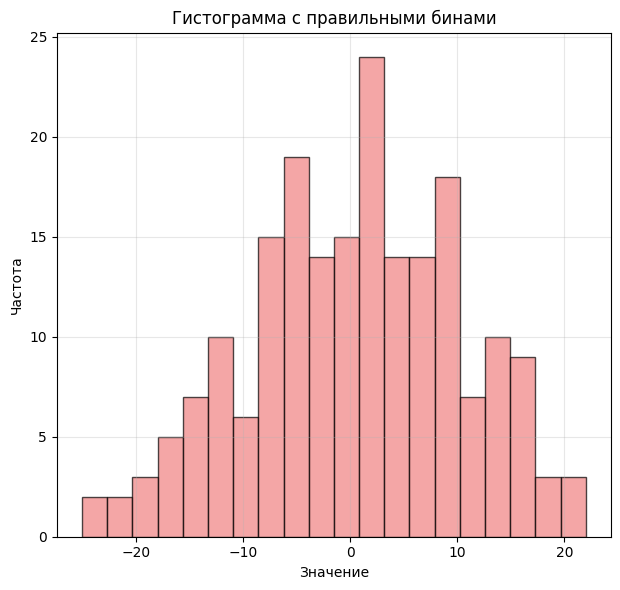

In [ ]:
import matplotlib.pyplot as plt

torch.manual_seed(42)
tensor = torch.normal(mean=0.0, std=10.0, size=(200,)).round().int()
print(tensor[:20])
print(tensor.shape)

values, bins = torch.histogram(tensor.float(), bins=20)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)
plt.hist(tensor.numpy(), bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.title('Гистограмма с правильными бинами')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()